In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [43]:
import warnings
warnings.filterwarnings('ignore')

In [44]:
df = pd.read_csv('Cancer_Data.csv')

In [45]:
df = df.drop('id', axis=1)


In [46]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [47]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [48]:
print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(f"Benign (0): {(y==0).sum()}")
print(f"Malignant (1): {(y==1).sum()}")

Dataset Shape: (569, 32)

Target Distribution:
Benign (0): 357
Malignant (1): 212


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 455
Testing samples: 114


In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print(f"\nNo NaN in scaled data: {not np.isnan(X_train_scaled).any()}")


No NaN in scaled data: False


In [52]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
y_pred = model.predict(X_test_scaled)

In [54]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("="*50)


MODEL PERFORMANCE METRICS
Accuracy:  0.9649 (96.49%)
Precision: 0.9756
Recall:    0.9302
F1-Score:  0.9524


In [55]:
cm = confusion_matrix(y_test, y_pred)


Text(0.5, 25.722222222222214, 'Predicted Label')

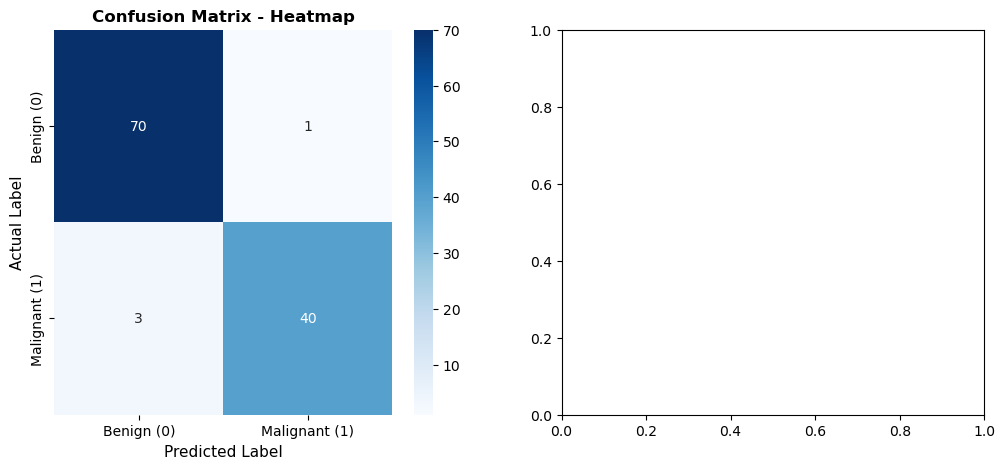

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix as Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
axes[0].set_title('Confusion Matrix - Heatmap', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

In [57]:
# Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix - Display', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [58]:
# Print confusion matrix details
print("\nConfusion Matrix Details:")
print("-"*40)
tn, fp, fn, tp = cm.ravel()
print(f"✓ True Negatives (Benign → Benign):       {tn}")
print(f"✗ False Positives (Benign → Malignant):   {fp}")
print(f"✗ False Negatives (Malignant → Benign):   {fn}")
print(f"✓ True Positives (Malignant → Malignant): {tp}")
print("-"*40)


Confusion Matrix Details:
----------------------------------------
✓ True Negatives (Benign → Benign):       70
✗ False Positives (Benign → Malignant):   1
✗ False Negatives (Malignant → Benign):   3
✓ True Positives (Malignant → Malignant): 40
----------------------------------------


In [59]:
# Calculate error rate
error_rate = (fp + fn) / (tn + fp + fn + tp)
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"Correct Predictions: {tn + tp}/{tn+fp+fn+tp} ({(tn+tp)/(tn+fp+fn+tp)*100:.2f}%)")


Error Rate: 0.0351 (3.51%)
Correct Predictions: 110/114 (96.49%)


In [60]:
print("\n" + "="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)']))
print("="*55)


CLASSIFICATION REPORT
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        71
Malignant (1)       0.98      0.93      0.95        43

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



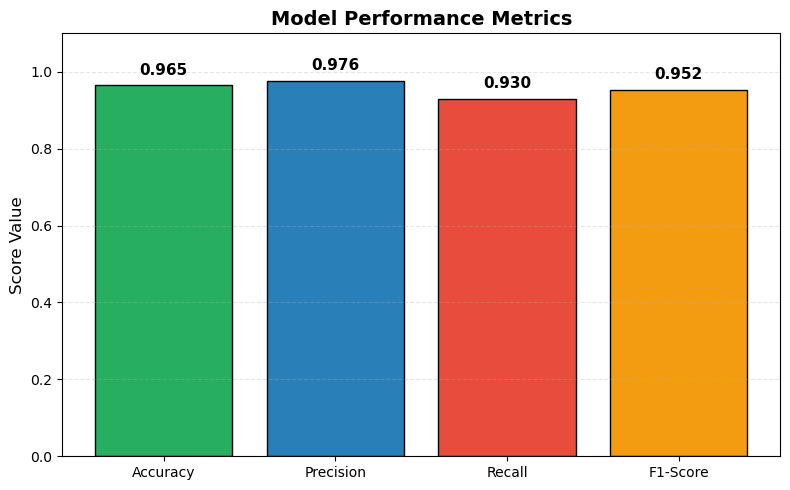

In [61]:
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics_names, metrics_values, 
               color=['#27ae60', '#2980b9', '#e74c3c', '#f39c12'],
               edgecolor='black', linewidth=1)
plt.ylim(0, 1.1)
plt.ylabel('Score Value', fontsize=12)
plt.title('Model Performance Metrics', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, val in zip(bars, metrics_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


=======================================================
SUMMARY
=======================================================

✓ Model used: Random Forest Classifier
✓ Total samples: 569
✓ Training samples: 455
✓ Testing samples: 114
✓ Features used: 31

Performance Summary:
• Accuracy:  96.49%
• Precision: 97.56%
• Recall:    93.02%
• F1-Score:  95.24%

The model performs well in detecting breast cancer 
with only 4 misclassifications out of 114 test samples.

=======================================================